Number of points: 20
Initial route: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Shuffled initial route: [19  3 10 15  9 18 16 14 17 11  6  2 13  8  7  4  5 12  0  1]
Best route:
[12 13  1  5 11  3 18 19  6 17  4 14  9  7 15 16  8  0 10  2]
Best cost:
4.6452004446438915


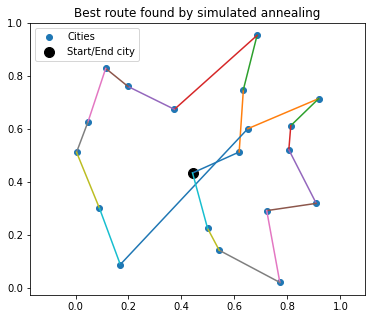

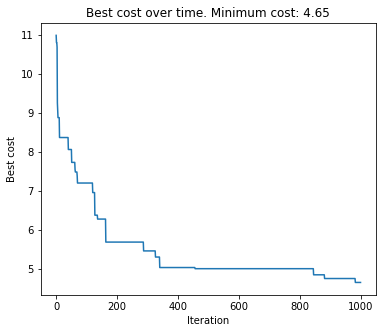

In [ ]:
# Exercise 7 - Part 1

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

def route_cost(route, points):
    """
    Compute total cost of a closed route using Euclidean distance.
    """
    total = 0
    n = len(route) # number of cities

    for i in range(n):
        current_city = route[i]
        next_city = route[(i + 1) % n]

        total += np.linalg.norm(points[current_city] - points[next_city])

    return total


def propose_swap(route):
    """
    Create a new route by swapping two randomly chosen cities.
    """
    new_route = route.copy()

    i, j = np.random.choice(len(route), size=2, replace=False)
    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route


def temperature(k):
    """
    Cooling schedule.
    """
    return 1 / np.sqrt(1 + k)


def simulated_annealing(points, num_iterations):
    """
    Simulated annealing algorithm for the travelling salesman problem.
    """
    #print("Initial points:")
    #print(points)
    print("Number of points:", len(points))
    n = len(points)

    # Start with a random route
    current_route = np.arange(n)
    print("Initial route:", current_route)
    np.random.shuffle(current_route)
    print("Shuffled initial route:", current_route)

    current_cost = route_cost(current_route, points)

    # Store best route found so far
    best_route = current_route.copy()
    best_cost = current_cost

    costs = []

    for k in range(num_iterations):
        T = temperature(k)

        # Generate candidate by swapping two cities
        candidate_route = propose_swap(current_route)
        candidate_cost = route_cost(candidate_route, points)

        delta = candidate_cost - current_cost

        # Accept if candidate is better
        if delta <= 0:
            current_route = candidate_route
            current_cost = candidate_cost

        # Otherwise accept with probability exp(-delta / T)
        else:
            acceptance_probability = np.exp(-delta / T)

            if np.random.rand() < acceptance_probability:
                current_route = candidate_route
                current_cost = candidate_cost

        # Update best solution
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs


# number of cities
n = 20

#point_type = "unit_circle"
point_type = "unit_square"

if point_type == "unit_square":
    points = np.random.rand(n, 2)

elif point_type == "unit_circle":
    theta = np.linspace(0, 2*np.pi, n, endpoint=False)

    points = np.column_stack((
        np.cos(theta),
        np.sin(theta)
    ))

# Run simulated annealing
best_route, best_cost, costs = simulated_annealing(
    points,
    num_iterations=1000
)

print("Best route:")
print(best_route)

print("Best cost:")
print(best_cost)


plt.figure(figsize=(6, 5))

for i in range(len(best_route)):
    p1 = points[best_route[i]]
    p2 = points[best_route[(i + 1) % len(best_route)]]

    plt.plot([p1[0], p2[0]], [p1[1], p2[1]])

plt.scatter(points[:, 0], points[:, 1], label="Cities")
plt.scatter(points[best_route[0], 0], points[best_route[0], 1], color="black", s=100, label="Start/End city")
plt.axis("equal")
plt.title("Best route found by simulated annealing")
plt.legend()
#plt.savefig("best_route.png", dpi=300)
plt.show()


plt.figure(figsize=(6, 5))
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("Best cost over time. Minimum cost: {:.2f}".format(best_cost))
#plt.savefig("best_cost_over_time.png", dpi=300)
plt.show()

Best route:
[ 7  3 11  5 10 19  2 18 14  8 17 16  6 12  0  1 13  9 15  4]
Best cost:
1365


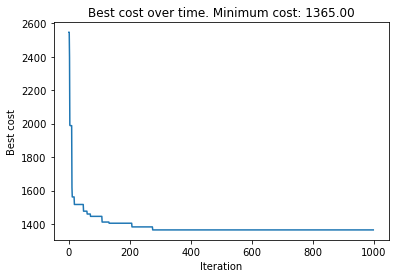

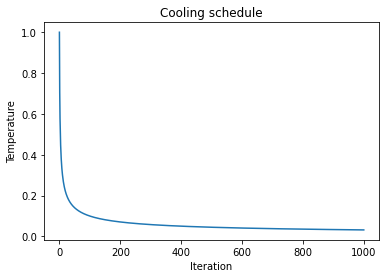

In [ ]:
# Exercise 7 - Part 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(10)

def route_cost(route, cost_matrix):
    """
    Computes the total cost of a route (using the cost matrix).

    input: the ordering of the cities. NB the route returns to the starting city. 
    """
    total = 0
    n = len(route)

    for i in range(n):
        current_city = route[i]
        next_city = route[(i + 1) % n] # modulu operator wraps the route back to the starting city
        total += cost_matrix[current_city, next_city]

    return total


def propose_swap(route):
    """
    Generate a new candidate route Yi from the current state Xi by swapping two random cities.
    """
    new_route = route.copy() # copying because we only want to modify the currentroute, if the algorithm accepts the new route

    i, j = np.random.choice(len(route), size=2, replace=False) # a city can not be swapped with itself because of replace=False
    new_route[i], new_route[j] = new_route[j], new_route[i]

    return new_route

def proposal_2opt(route):
    """
    Create a new route by selecting one random segment and swapping it with its left neighbour.
    Example: If the route is [0, 1, 2, 3, 4] and we select index 2, the new route will be [0, 2, 1, 3, 4].
    """
    new_route = route.copy()

    i = np.random.randint(1, len(route) - 1)
    new_route[i-1], new_route[i] = new_route[i], new_route[i-1]

    return new_route


def temperature(k):
    """
    Cooling scheme:
    """
    #return - k
    return 1 / np.sqrt(1 + k)
    #return 1 / np.log(2 + k)
    #return np.exp(-k / 1000)


def simulated_annealing(cost_matrix, num_iterations):
    n = cost_matrix.shape[0] # number of cities

    # Initial route
    current_route = np.arange(n)
    np.random.shuffle(current_route) # shuffle the initial route to start with a random one

    current_cost = route_cost(current_route, cost_matrix)

    best_route = current_route.copy() # initialize best route as the initial route
    best_cost = current_cost          # initialize best cost as the cost of the initial route

    costs = []

    for k in range(num_iterations):
        T = temperature(k)

        candidate_route = propose_swap(current_route)
        #candidate_route = proposal_2opt(current_route)
        candidate_cost = route_cost(candidate_route, cost_matrix)

        # Difference in cost
        delta = candidate_cost - current_cost

        # Accept if better
        if delta <= 0:
            current_route = candidate_route
            current_cost = candidate_cost

        # If not better, still accept with probability exp(-delta / T)
        else:
            acceptance_probability = np.exp(-delta / T)

            if np.random.rand() < acceptance_probability:
                current_route = candidate_route
                current_cost = candidate_cost

        # Save best solution found so far
        if current_cost < best_cost:
            best_route = current_route.copy()
            best_cost = current_cost

        costs.append(best_cost)

    return best_route, best_cost, costs


# Load cost matrix from CSV
cost_matrix = pd.read_csv("cost.csv", header=None).values

best_route, best_cost, costs = simulated_annealing(
    cost_matrix,
    num_iterations=1000
)

print("Best route:")
print(best_route)

print("Best cost:")
print(best_cost)


# Plot improvement of best cost
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Best cost")
plt.title("Best cost over time. Minimum cost: {:.2f}".format(best_cost))
#plt.savefig("best_cost_over_time_matrix.png", dpi=300)
plt.show()

# PLot of cooling schedule
plt.plot([temperature(k) for k in range(1000)])
plt.xlabel("Iteration")
plt.ylabel("Temperature")
plt.title("Cooling schedule")
plt.show()

In [1]:
# Exercise 8 - Part 1

# Exercise 13 in Chapter 8 of Ross

import numpy as np
import matplotlib.pyplot as plt


def inverse_edf(X, p):
    """
    Inverse empirical distribution function.
    This is equivalent to sampling one observation from X with replacement.
    """
    X = np.asarray(X)
    n = len(X)
    sorted_X = np.sort(X)

    index = int(np.ceil(p * n)) - 1
    index = max(0, min(index, n - 1))   # keep index valid

    return sorted_X[index]


def bootstrap_sample_inverse(X, rng):
    """
    Generate one bootstrap sample using the inverse EDF method.
    """
    X = np.asarray(X)
    n = len(X)

    return np.array([
        inverse_edf(X, rng.uniform(0, 1))
        for _ in range(n)
    ])


def part1(seed=42):
    rng = np.random.default_rng(seed)

    X = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69])

    a = -5
    b = 5
    B = 1000

    sample_mean = np.mean(X)

    bootstrap_means = []

    for _ in range(B):
        sample = bootstrap_sample_inverse(X, rng)
        bootstrap_means.append(np.mean(sample))

    bootstrap_means = np.array(bootstrap_means)

    theta = bootstrap_means - sample_mean

    probability = np.mean((a <= theta) & (theta <= b))

    print("Part 1")
    print("Sample mean:", sample_mean)
    print("Estimated probability:")
    print(f"P({a} <= Xbar* - Xbar <= {b}) = {probability}")
    print(f"Percentage = {100 * probability:.2f}%")
    print()




In [2]:
# Exercise 8 - Part 2

# Exercise 15 in Chapter 8 of Ross


def part2(seed=42):
    rng = np.random.default_rng(seed)

    X = np.array([5, 4, 9, 6, 21, 17, 11, 20, 7, 10, 21, 15, 13, 16, 8])

    B = 1000

    sample_variance = np.var(X, ddof=1)

    bootstrap_variances = []

    for _ in range(B):
        sample = bootstrap_sample_inverse(X, rng)
        bootstrap_variances.append(np.var(sample, ddof=1))

    bootstrap_variances = np.array(bootstrap_variances)

    estimated_variance_of_variance_estimator = np.var(bootstrap_variances, ddof=1)

    print("Part 2")
    print("Sample variance:", sample_variance)
    print("Mean bootstrap variance estimate:", np.mean(bootstrap_variances))
    print("Estimated variance of the sample variance estimator:")
    print(estimated_variance_of_variance_estimator)
    print()




Part 1
Sample mean: 76.7
Estimated probability:
P(-5 <= Xbar* - Xbar <= 5) = 0.772
Percentage = 77.20%

Part 2
Sample variance: 34.31428571428571
Mean bootstrap variance estimate: 31.724819047619043
Estimated variance of the sample variance estimator:
57.845699010938375

Part 3
Sample mean: 4.127878537302188
Sample median: 1.8607921725383818
Bootstrap estimate of variance of sample mean: 0.2989694252142566
Bootstrap estimate of variance of sample median: 0.016612764814614045


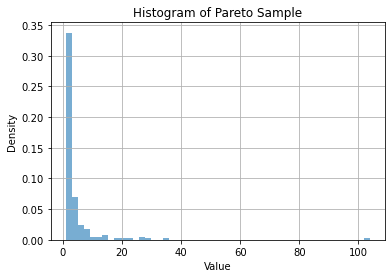

In [3]:
# Exercise 8 - Part 3

# Write a program that takes a sample as input and returns the sample median together
# with a bootstrap estimate of the variance of the median, based on k= 100 bootstrap
# replicates. Then run the program with a sample of n = 200 Pareto(β= 1, k= 1.05)
# distributed observations.


def sample_pareto(beta, shape, size, rng):
    """
    Generate Pareto(beta, shape) observations.

    Here beta is the scale parameter and shape is the Pareto shape parameter.
    The distribution has CDF:

        F(x) = 1 - (beta / x)^shape,  x >= beta
    """
    U = rng.uniform(0, 1, size=size)
    return beta * (1 - U) ** (-1 / shape)


def median_and_bootstrap_variance(X, B=100, seed=42):
    """
    Takes a sample X and returns:
    - sample median
    - bootstrap estimate of variance of the sample median
    """
    rng = np.random.default_rng(seed)

    sample_median = np.median(X)

    bootstrap_medians = []

    for _ in range(B):
        sample = bootstrap_sample_inverse(X, rng)
        bootstrap_medians.append(np.median(sample))

    bootstrap_medians = np.array(bootstrap_medians)

    bootstrap_variance_median = np.var(bootstrap_medians, ddof=1)

    return sample_median, bootstrap_variance_median


def part3(seed=42):
    rng = np.random.default_rng(seed)

    n = 200
    B = 100

    beta = 1
    shape = 1.05

    X = sample_pareto(beta=beta, shape=shape, size=n, rng=rng)

    sample_mean = np.mean(X)
    sample_median = np.median(X)

    bootstrap_means = []
    bootstrap_medians = []

    for _ in range(B):
        sample = bootstrap_sample_inverse(X, rng)

        bootstrap_means.append(np.mean(sample))
        bootstrap_medians.append(np.median(sample))

    bootstrap_means = np.array(bootstrap_means)
    bootstrap_medians = np.array(bootstrap_medians)

    variance_mean = np.var(bootstrap_means, ddof=1)
    variance_median = np.var(bootstrap_medians, ddof=1)

    print("Part 3")
    print("Sample mean:", sample_mean)
    print("Sample median:", sample_median)
    print("Bootstrap estimate of variance of sample mean:", variance_mean)
    print("Bootstrap estimate of variance of sample median:", variance_median)



    plt.hist(X, bins=50, density=True, alpha=0.6)
    plt.title("Histogram of Pareto Sample")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.grid()
    plt.show()



part1()
part2()
part3()